# Test Systems: A (Template) vs B (Enc-Dec)

Evaluate both sarcasm-rewriting systems on the **held-out test set** by default using three automatic metrics:

| Metric | What it measures |
|---|---|
| **Anchor preservation** | Do named entities, numbers, etc. survive the rewrite? |
| **Semantic similarity** | Does the rewrite stay on topic? (sentence-transformer cosine sim) |
| **Classifier flip rate** | Does a trained detector predict the *target* label on the rewrite? (All available checkpoints for this split: TF–IDF LogReg, BiLSTM, Transformer — see per-detector table.) |

Each headline is rewritten in its natural direction:
- label=0 (neutral) → rewrite to sarcastic (**n2s**)
- label=1 (sarcastic) → rewrite to neutral (**s2n**)

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

print(f"Project root: {PROJECT_ROOT}")

Project root: E:\CS4248_Project


## 1. Load held-out test set (with anchors)

In [2]:
SPLIT_NAME = "standard"
EVAL_SPLIT_NAME = "test"  # switch to "dev" only for faster iteration

df_all = pd.read_json("../artifacts/data/cleaned_with_anchors.jsonl", lines=True)

with open(f"../artifacts/splits/{SPLIT_NAME}.json", "r", encoding="utf-8") as f:
    split = json.load(f)

eval_ids = set(split[EVAL_SPLIT_NAME])
eval_source_df = df_all[df_all["id"].isin(eval_ids)].copy().reset_index(drop=True)

print(f"Split strategy: {SPLIT_NAME}")
print(f"Evaluation subset: {EVAL_SPLIT_NAME}")
print(f"{EVAL_SPLIT_NAME.title()} set: {len(eval_source_df)} rows")
print(f"  label=0 (neutral):   {(eval_source_df['label'] == 0).sum()}")
print(f"  label=1 (sarcastic): {(eval_source_df['label'] == 1).sum()}")
eval_source_df[["id", "text", "label"]].head()


Split strategy: standard
Evaluation subset: test
Test set: 2851 rows
  label=0 (neutral):   1495
  label=1 (sarcastic): 1356


,id,text,label
0,sar_000001,thirtysomething scientists unveil doomsday clo...,1
1,sar_000009,shadow government getting too large to meet in...,1
2,sar_000010,lots of parents know this scenario,0
3,sar_000016,uber ceo travis kalanick stepping down from tr...,0
4,sar_000032,teenage gunfight with isis,0


## 2. Initialize systems and evaluation tools

In [3]:
from systems.system_a.system_a_template import SystemATemplate
from systems.system_b_encdec import generate_candidates as system_b_generate, batch_generate as system_b_batch
from systems.system_a.template_utils import preserves_anchors, get_anchor_texts
from systems.system_b_utils import MODEL_DIR as SYSTEM_B_MODEL_DIR
from similarity.semantic_similarity import semantic_similarity, batch_semantic_similarity

system_a = SystemATemplate()
SYSTEM_B_MODE = "finetuned_local"
SYSTEM_B_MODEL_PATH = Path(SYSTEM_B_MODEL_DIR)
if not SYSTEM_B_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Fine-tuned System B model not found at {SYSTEM_B_MODEL_PATH}. "
        "Train it with systems/system_b_train.py before running this notebook."
    )

print("System A (Template):  ready")
print(f"System B (Enc-Dec):   using fine-tuned weights from {SYSTEM_B_MODEL_PATH}")


def direction_for_label(label: int) -> str:
    return "n2s" if label == 0 else "s2n"


def target_label(label: int) -> int:
    return 1 if label == 0 else 0


System A (Template):  ready
System B (Enc-Dec):   using fine-tuned weights from E:\CS4248_Project\artifacts\system_b\model


## 3. Style detectors (for flip-rate evaluation)

Checkpoints live under `artifacts/classifiers/{transformer,rnn,logreg}/<SPLIT_NAME>/`. Every **available** detector is run on the rewrites; summary tables include flip rates for each. Canonical columns `prob_*`, `pred_*`, `flip_*` use the **strongest available** critic (transformer → RNN → LogReg).

In [4]:
from classifiers.batch_style_probs import (
    DETECTOR_ORDER,
    available_detectors,
    batch_probs_for_all_detectors,
    classifier_dir,
)

REQUIRED_STYLE_DETECTORS = DETECTOR_ORDER
_avail = available_detectors(PROJECT_ROOT, SPLIT_NAME)
print("Detector checkpoints for this split:")
for name in REQUIRED_STYLE_DETECTORS:
    path = _avail.get(name)
    if path:
        print(f"  {name:12s}  OK - {path}")
    else:
        expected = classifier_dir(PROJECT_ROOT, name, SPLIT_NAME)
        print(f"  {name:12s}  MISSING (expected under {expected})")

missing_required = [name for name in REQUIRED_STYLE_DETECTORS if _avail.get(name) is None]
if missing_required:
    raise FileNotFoundError(
        f"Missing required classifier checkpoints for split {SPLIT_NAME!r}: {missing_required}. "
        "Train all three with classifiers/train_classifiers.py before running this notebook."
    )

PRIMARY_STYLE_DETECTOR = REQUIRED_STYLE_DETECTORS[0]
_smoke = batch_probs_for_all_detectors(
    ["Nation relieved as experts confirm everything is fine"],
    PROJECT_ROOT,
    SPLIT_NAME,
    detectors=REQUIRED_STYLE_DETECTORS,
)
_p = float(_smoke[PRIMARY_STYLE_DETECTOR][0])
print()
print(f"Smoke test - primary detector ({PRIMARY_STYLE_DETECTOR}): pred={int(_p >= 0.5)}, prob_sarcastic={_p:.3f}")


Detector checkpoints for this split:
  transformer   OK - E:\CS4248_Project\artifacts\classifiers\transformer\standard
  rnn           OK - E:\CS4248_Project\artifacts\classifiers\rnn\standard
  logreg        OK - E:\CS4248_Project\artifacts\classifiers\logreg\standard

Smoke test - primary detector (transformer): pred=1, prob_sarcastic=0.996


e:\CS4248_Project\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
e:\CS4248_Project\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
e:\CS4248_Project\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.8.0. This might lead to brea

## 4. Run both systems on the held-out test set

The evaluation runs in three phases to avoid per-row bottlenecks:

1. **Rewrite** — collect rewrites from both systems (System B is the slowest step)
2. **Score similarity** — batch-encode all texts with the sentence-transformer, then compute cosine similarity
3. **Score classifiers** — batch-predict all rewrites with every available detector (LogReg / RNN / Transformer) for this split

In [5]:
# ========== PHASE 1: collect rewrites ==========
# System A is template-based (instant), so run it in a fast loop.
all_texts = eval_source_df["text"].tolist()
all_labels = eval_source_df["label"].astype(int).tolist()
all_anchors = [row.get("anchors", {}) for _, row in eval_source_df.iterrows()]
all_directions = [direction_for_label(l) for l in all_labels]

print("Phase 1a · System A rewrites (template)...")
rewrites_a = [
    system_a.rewrite(t, a, d)
    for t, a, d in tqdm(zip(all_texts, all_anchors, all_directions),
                        total=len(all_texts), desc="System A")
]

# System B: batched GPU generation — much faster than one-by-one.
BATCH_SIZE = 16
n_batches = (len(all_texts) + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Phase 1b · System B rewrites ({n_batches} batches, batch_size={BATCH_SIZE})...")

rewrites_b_lists = []
for i in tqdm(range(0, len(all_texts), BATCH_SIZE), total=n_batches, desc="System B (batched)"):
    chunk = system_b_batch(
        all_texts[i : i + BATCH_SIZE],
        all_directions[i : i + BATCH_SIZE],
        k=1,
        batch_size=BATCH_SIZE,
        mode=SYSTEM_B_MODE,
        finetuned_model_dir=SYSTEM_B_MODEL_PATH,
    )
    rewrites_b_lists.extend(chunk)
rewrites_b = [cands[0] for cands in rewrites_b_lists]

eval_df = pd.DataFrame({
    "id": eval_source_df["id"].tolist(),
    "label": all_labels,
    "direction": all_directions,
    "target_label": [target_label(l) for l in all_labels],
    "original": all_texts,
    "anchors": all_anchors,
    "rewrite_a": rewrites_a,
    "rewrite_b": rewrites_b,
})

print(f"Phase 1 done — {len(eval_df)} rewrites collected.")

# ========== PHASE 2: batch semantic similarity ==========
print("Phase 2 · computing semantic similarity (batched)...")
originals = eval_df["original"].tolist()
eval_df["sim_a"] = batch_semantic_similarity(originals, eval_df["rewrite_a"].tolist())
eval_df["sim_b"] = batch_semantic_similarity(originals, eval_df["rewrite_b"].tolist())
print("Phase 2 done.")

# ========== PHASE 3: batch classify (all available detectors) + anchor check ==========
from classifiers.batch_style_probs import batch_probs_for_all_detectors

print("Phase 3 · classifier predictions + anchor checks...")
probs_a_by_det = batch_probs_for_all_detectors(
    eval_df["rewrite_a"].tolist(), PROJECT_ROOT, SPLIT_NAME, detectors=REQUIRED_STYLE_DETECTORS
)
probs_b_by_det = batch_probs_for_all_detectors(
    eval_df["rewrite_b"].tolist(), PROJECT_ROOT, SPLIT_NAME, detectors=REQUIRED_STYLE_DETECTORS
)
LOADED_STYLE_DETECTORS = list(REQUIRED_STYLE_DETECTORS)
missing_outputs = [name for name in REQUIRED_STYLE_DETECTORS if name not in probs_a_by_det or name not in probs_b_by_det]
if missing_outputs:
    raise RuntimeError(f"Expected detector outputs for all classifiers, missing: {missing_outputs}")

for name in LOADED_STYLE_DETECTORS:
    pa, pb = probs_a_by_det[name], probs_b_by_det[name]
    eval_df[f"prob_a_{name}"] = pa
    eval_df[f"pred_a_{name}"] = (pa >= 0.5).astype(int)
    eval_df[f"flip_a_{name}"] = (eval_df[f"pred_a_{name}"] == eval_df["target_label"]).astype(int)
    eval_df[f"prob_b_{name}"] = pb
    eval_df[f"pred_b_{name}"] = (pb >= 0.5).astype(int)
    eval_df[f"flip_b_{name}"] = (eval_df[f"pred_b_{name}"] == eval_df["target_label"]).astype(int)

# Canonical columns: primary (strongest) critic — matches PRIMARY_STYLE_DETECTOR from setup cell
eval_df["prob_a"] = eval_df[f"prob_a_{PRIMARY_STYLE_DETECTOR}"]
eval_df["pred_a"] = eval_df[f"pred_a_{PRIMARY_STYLE_DETECTOR}"]
eval_df["flip_a"] = eval_df[f"flip_a_{PRIMARY_STYLE_DETECTOR}"]
eval_df["prob_b"] = eval_df[f"prob_b_{PRIMARY_STYLE_DETECTOR}"]
eval_df["pred_b"] = eval_df[f"pred_b_{PRIMARY_STYLE_DETECTOR}"]
eval_df["flip_b"] = eval_df[f"flip_b_{PRIMARY_STYLE_DETECTOR}"]
print(f"  Detectors used: {LOADED_STYLE_DETECTORS}; primary → flip_* columns: {PRIMARY_STYLE_DETECTOR}")

eval_df["anchor_ok_a"] = [
    preserves_anchors(a, r) for a, r in zip(eval_df["anchors"], eval_df["rewrite_a"])
]
eval_df["anchor_ok_b"] = [
    preserves_anchors(a, r) for a, r in zip(eval_df["anchors"], eval_df["rewrite_b"])
]

print(f"All phases complete — {len(eval_df)} rows.")
eval_df.head()

Phase 1a · System A rewrites (template)...


System A:   0%|          | 0/2851 [00:00<?, ?it/s]

Phase 1b · System B rewrites (179 batches, batch_size=16)...


System B (batched):   0%|          | 0/179 [00:00<?, ?it/s]

Phase 1 done — 2851 rewrites collected.
Phase 2 · computing semantic similarity (batched)...
Phase 2 done.
Phase 3 · classifier predictions + anchor checks...


e:\CS4248_Project\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
e:\CS4248_Project\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
e:\CS4248_Project\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.5.2 when using version 1.8.0. This might lead to brea

  Detectors used: ['transformer', 'rnn', 'logreg']; primary → flip_* columns: transformer
All phases complete — 2851 rows.


,id,label,direction,target_label,original,anchors,rewrite_a,rewrite_b,sim_a,sim_b,...,pred_b_logreg,flip_b_logreg,prob_a,pred_a,flip_a,prob_b,pred_b,flip_b,anchor_ok_a,anchor_ok_b
0,sar_000001,1,s2n,0,thirtysomething scientists unveil doomsday clo...,"{'entities': [], 'numbers': [], 'capitals': []...",thirtysomething scientists unveil doomsday clo...,the world unveils 30-something biannual time o...,1.000000,0.815802,...,1,0,0.987572,1,0,0.213065,0,1,True,True
1,sar_000009,1,s2n,0,shadow government getting too large to meet in...,"{'entities': [], 'numbers': [], 'capitals': []...",shadow government getting too large to meet in...,shadow government becomes overcrowded to join ...,1.000000,0.927011,...,1,0,0.991294,1,0,0.987096,1,0,True,True
2,sar_000010,0,n2s,1,lots of parents know this scenario,"{'entities': [], 'numbers': [], 'capitals': []...",Experts confirm lots of parents know this scen...,few parents even comprehend how great life sho...,0.953827,0.804389,...,0,0,0.990575,1,1,0.169733,0,0,True,True
3,sar_000016,0,n2s,1,uber ceo travis kalanick stepping down from tr...,"{'entities': [{'text': 'travis kalanick', 'sta...",Nation relieved as uber ceo travis kalanick st...,uber ceo travis kalanick turns in the resignat...,0.945939,0.943563,...,0,0,0.820539,1,1,0.010122,0,0,True,True
4,sar_000032,0,n2s,1,teenage gunfight with isis,"{'entities': [], 'numbers': [], 'capitals': []...",Experts confirm teenage gunfight with isis,teenager battle with wasis for the only reason...,0.951185,0.672816,...,1,1,0.410433,0,0,0.128700,0,0,True,True


## 5. Aggregate metrics

In [6]:
def summarize_system(eval_df, suffix):
    """Summarize metrics for one system (suffix = '_a' or '_b')."""
    return {
        "Anchor preservation (%)": eval_df[f"anchor_ok{suffix}"].mean() * 100,
        "Semantic similarity (mean)": eval_df[f"sim{suffix}"].mean(),
        f"Flip rate — primary ({PRIMARY_STYLE_DETECTOR}) (%)": eval_df[f"flip{suffix}"].mean() * 100,
    }


overall = pd.DataFrame({
    "System A (Template)": summarize_system(eval_df, "_a"),
    "System B (Enc-Dec)": summarize_system(eval_df, "_b"),
}).round(2)

print(f"=== OVERALL — {SPLIT_NAME} split / {EVAL_SPLIT_NAME} set (both directions combined) ===\n")
display(overall)

flip_detail_a = {det: eval_df[f"flip_a_{det}"].mean() * 100 for det in LOADED_STYLE_DETECTORS}
flip_detail_b = {det: eval_df[f"flip_b_{det}"].mean() * 100 for det in LOADED_STYLE_DETECTORS}
flip_by_detector = pd.DataFrame({
    "System A (Template)": flip_detail_a,
    "System B (Enc-Dec)": flip_detail_b,
}).round(2)
print(f"\n=== Flip rate (%) by detector — same split as training ===\n")
display(flip_by_detector)

=== OVERALL — standard split / test set (both directions combined) ===



,System A (Template),System B (Enc-Dec)
Anchor preservation (%),100.00,86.95
Semantic similarity (mean),0.98,0.88
Flip rate — primary (transformer) (%),28.83,27.43



=== Flip rate (%) by detector — same split as training ===



,System A (Template),System B (Enc-Dec)
transformer,28.83,27.43
rnn,32.62,33.04
logreg,25.46,29.64


In [7]:
print("=== BREAKDOWN BY DIRECTION ===\n")

for direction, label_name in [("n2s", "Neutral → Sarcastic"), ("s2n", "Sarcastic → Neutral")]:
    sub = eval_df[eval_df["direction"] == direction]
    breakdown = pd.DataFrame({
        "System A (Template)": summarize_system(sub, "_a"),
        "System B (Enc-Dec)": summarize_system(sub, "_b"),
    }).round(2)
    print(f"\n--- {label_name}  ({len(sub)} headlines) ---")
    display(breakdown)
    flip_sub = pd.DataFrame({
        "System A (Template)": {det: sub[f"flip_a_{det}"].mean() * 100 for det in LOADED_STYLE_DETECTORS},
        "System B (Enc-Dec)": {det: sub[f"flip_b_{det}"].mean() * 100 for det in LOADED_STYLE_DETECTORS},
    }).round(2)
    print("  Flip (%) by detector:")
    display(flip_sub)

=== BREAKDOWN BY DIRECTION ===


--- Neutral → Sarcastic  (1495 headlines) ---


,System A (Template),System B (Enc-Dec)
Anchor preservation (%),100.00,89.10
Semantic similarity (mean),0.97,0.89
Flip rate — primary (transformer) (%),45.95,12.37


  Flip (%) by detector:


,System A (Template),System B (Enc-Dec)
transformer,45.95,12.37
rnn,44.41,25.95
logreg,34.92,23.21



--- Sarcastic → Neutral  (1356 headlines) ---


,System A (Template),System B (Enc-Dec)
Anchor preservation (%),100.00,84.59
Semantic similarity (mean),1.00,0.86
Flip rate — primary (transformer) (%),9.96,44.03


  Flip (%) by detector:


,System A (Template),System B (Enc-Dec)
transformer,9.96,44.03
rnn,19.62,40.86
logreg,15.04,36.73


## 6. Visualize comparison

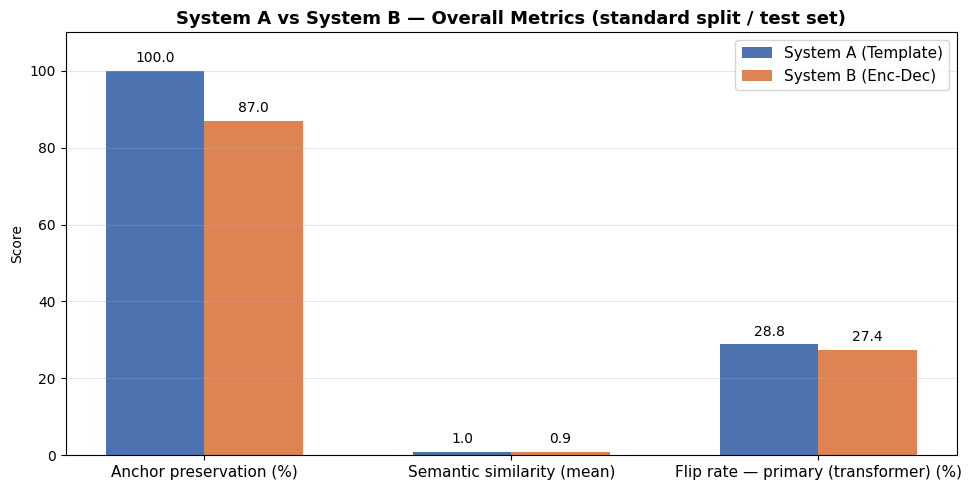

In [8]:
import matplotlib.pyplot as plt

metrics_names = list(overall.index)
sys_a_vals = overall["System A (Template)"].values
sys_b_vals = overall["System B (Enc-Dec)"].values

x = np.arange(len(metrics_names))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, sys_a_vals, width, label="System A (Template)", color="#4c72b0")
bars2 = ax.bar(x + width / 2, sys_b_vals, width, label="System B (Enc-Dec)", color="#dd8452")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel("Score")
ax.set_title(f"System A vs System B — Overall Metrics ({SPLIT_NAME} split / {EVAL_SPLIT_NAME} set)", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

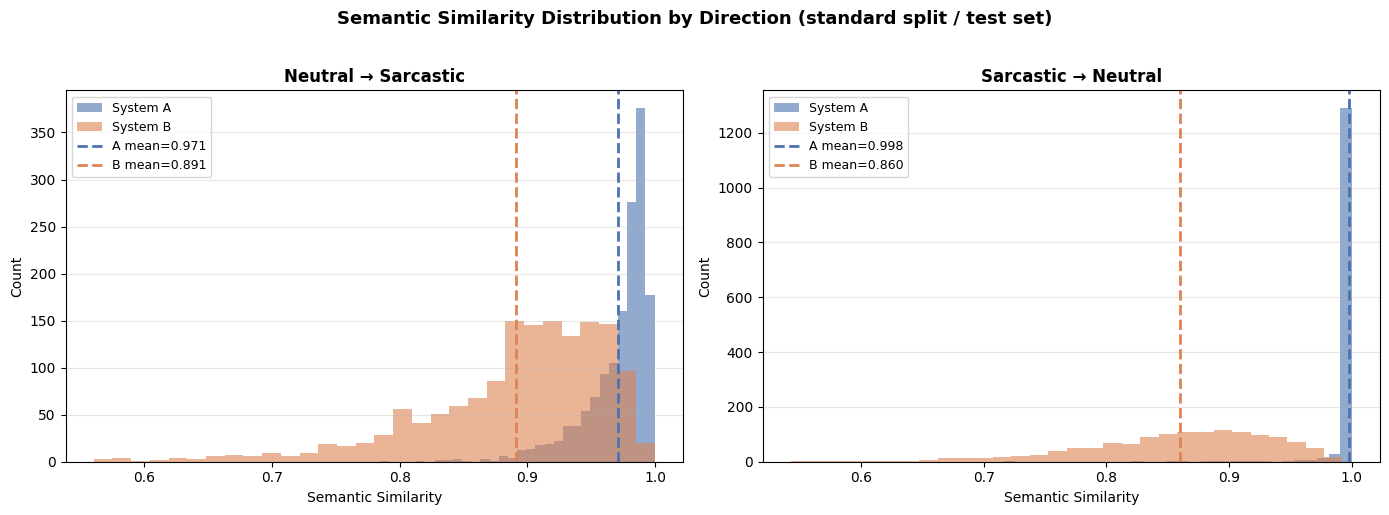

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (direction, title) in zip(axes, [("n2s", "Neutral → Sarcastic"), ("s2n", "Sarcastic → Neutral")]):
    sub = eval_df[eval_df["direction"] == direction]

    sim_a = sub["sim_a"]
    sim_b = sub["sim_b"]

    ax.hist(sim_a, bins=30, alpha=0.6, label="System A", color="#4c72b0")
    ax.hist(sim_b, bins=30, alpha=0.6, label="System B", color="#dd8452")
    ax.axvline(sim_a.mean(), color="#4c72b0", linestyle="--", linewidth=2, label=f"A mean={sim_a.mean():.3f}")
    ax.axvline(sim_b.mean(), color="#dd8452", linestyle="--", linewidth=2, label=f"B mean={sim_b.mean():.3f}")
    ax.set_xlabel("Semantic Similarity")
    ax.set_ylabel("Count")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"Semantic Similarity Distribution by Direction ({SPLIT_NAME} split / {EVAL_SPLIT_NAME} set)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Sample rewrites (qualitative inspection)

Spot-check a few examples from each system and direction.

In [10]:
N_SAMPLES = 5

for direction, title in [("n2s", "Neutral → Sarcastic"), ("s2n", "Sarcastic → Neutral")]:
    sub = eval_df[eval_df["direction"] == direction].sample(N_SAMPLES, random_state=42)
    print(f"\n{'='*80}")
    print(f"  {title}")
    print(f"{'='*80}")

    for _, r in sub.iterrows():
        print(f"\n  ORIGINAL : {r['original']}")
        print(f"  SYSTEM A : {r['rewrite_a']}")
        fl_a = " ".join(f"{d}={int(r[f'flip_a_{d}'])}" for d in LOADED_STYLE_DETECTORS)
        fl_b = " ".join(f"{d}={int(r[f'flip_b_{d}'])}" for d in LOADED_STYLE_DETECTORS)
        print(f"    anchor={r['anchor_ok_a']}  sim={r['sim_a']:.3f}  flip[{PRIMARY_STYLE_DETECTOR}]={r['flip_a']}  ({fl_a})")
        print(f"  SYSTEM B : {r['rewrite_b']}")
        print(f"    anchor={r['anchor_ok_b']}  sim={r['sim_b']:.3f}  flip[{PRIMARY_STYLE_DETECTOR}]={r['flip_b']}  ({fl_b})")
        print(f"  {'-'*76}")


  Neutral → Sarcastic

  ORIGINAL : an american in paris on broadway
  SYSTEM A : Experts confirm an american in paris on broadway
    anchor=True  sim=0.926  flip[transformer]=1  (transformer=1 rnn=0 logreg=0)
  SYSTEM B : an american makes his way to paris on broadway after being shot in the head.
    anchor=True  sim=0.893  flip[transformer]=0  (transformer=0 rnn=0 logreg=0)
  ----------------------------------------------------------------------------

  ORIGINAL : 30 ways to offend your toddler
  SYSTEM A : 30 ways to offend your toddler in stunning development
    anchor=True  sim=0.894  flip[transformer]=0  (transformer=0 rnn=0 logreg=0)
  SYSTEM B : 30 ways to offend your toddler without insults in short.
    anchor=True  sim=0.963  flip[transformer]=0  (transformer=0 rnn=0 logreg=0)
  ----------------------------------------------------------------------------

  ORIGINAL : is under armour copying nike's playbook?
  SYSTEM A : is under armour copying nike's playbook? for some

## 8. Verdict

In [11]:
print("=" * 60)
print(f"  SYSTEM COMPARISON SUMMARY  ({SPLIT_NAME} split / {EVAL_SPLIT_NAME} set)")
print("=" * 60)

for metric in metrics_names:
    va = overall.loc[metric, "System A (Template)"]
    vb = overall.loc[metric, "System B (Enc-Dec)"]
    winner = "A" if va > vb else ("B" if vb > va else "tie")
    print(f"  {metric:35s}  A={va:6.2f}  B={vb:6.2f}  → {'System ' + winner if winner != 'tie' else 'TIE'}")

print()

flip_a = eval_df["flip_a"].mean() * 100
flip_b = eval_df["flip_b"].mean() * 100
anchor_a = eval_df["anchor_ok_a"].mean() * 100
anchor_b = eval_df["anchor_ok_b"].mean() * 100

if flip_b > flip_a + 2:
    print("  System B (Enc-Dec) achieves a meaningfully higher flip rate,")
    print(f"  on the primary detector ({PRIMARY_STYLE_DETECTOR}), suggesting its rewrites")
    print("  shift the critic more. Check per-detector flip table — conclusions can differ")
    print("  across LogReg vs RNN vs Transformer. Also check anchors and similarity.")
elif flip_a > flip_b + 2:
    print("  System A (Template) achieves a higher flip rate on the primary detector")
    print(f"  ({PRIMARY_STYLE_DETECTOR}). Compare other detectors in the flip-by-detector table;")
    print("  template cues may correlate with some critics more than others.")
else:
    print("  Both systems have similar flip rates on the primary detector.")
    print("  Use the per-detector table if detectors disagree.")

print("=" * 60)

  SYSTEM COMPARISON SUMMARY  (standard split / test set)
  Anchor preservation (%)              A=100.00  B= 86.95  → System A
  Semantic similarity (mean)           A=  0.98  B=  0.88  → System A
  Flip rate — primary (transformer) (%)  A= 28.83  B= 27.43  → System A

  Both systems have similar flip rates on the primary detector.
  Use the per-detector table if detectors disagree.


## 8. Save sample conversions for human evaluation

Export a stratified random sample of rewrites for manual review. The CSV contains the original headline, both system rewrites, automatic scores, and blank columns for human ratings.

In [12]:
SAMPLE_N = 50
SEED = 42
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "human_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sample_frames = []
for direction in ["n2s", "s2n"]:
    subset = eval_df[eval_df["direction"] == direction]
    n = min(SAMPLE_N // 2, len(subset))
    sample_frames.append(subset.sample(n=n, random_state=SEED))

sample_df = pd.concat(sample_frames).sample(frac=1, random_state=SEED).reset_index(drop=True)

_base_cols = [
    "id", "direction", "original",
    "rewrite_a", "sim_a", "flip_a", "anchor_ok_a",
    "rewrite_b", "sim_b", "flip_b", "anchor_ok_b",
]
_extra = [f"flip_a_{d}" for d in LOADED_STYLE_DETECTORS] + [f"flip_b_{d}" for d in LOADED_STYLE_DETECTORS]
human_df = sample_df[_base_cols + [c for c in _extra if c in sample_df.columns]].copy()

human_df["human_fluency_a"] = ""
human_df["human_adequacy_a"] = ""
human_df["human_sarcasm_a"] = ""
human_df["human_fluency_b"] = ""
human_df["human_adequacy_b"] = ""
human_df["human_sarcasm_b"] = ""
human_df["human_preference"] = ""

out_path = OUTPUT_DIR / f"samples_{SPLIT_NAME}_{EVAL_SPLIT_NAME}.csv"
human_df.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Saved {len(human_df)} samples -> {out_path}")
human_df.head()

Saved 50 samples -> E:\CS4248_Project\artifacts\human_eval\samples_standard_test.csv


,id,direction,original,rewrite_a,sim_a,flip_a,anchor_ok_a,rewrite_b,sim_b,flip_b,...,flip_b_transformer,flip_b_rnn,flip_b_logreg,human_fluency_a,human_adequacy_a,human_sarcasm_a,human_fluency_b,human_adequacy_b,human_sarcasm_b,human_preference
0,sar_026410,n2s,"holy mother of all that is good, 'curb your en...",Experts confirm holy mother of all that is goo...,0.968302,1,True,"holy mother of all that is good, 'curb your en...",0.875177,1,...,1,1,1,,,,,,,
1,sar_015964,s2n,bar mitzvah marks local boy's passage into mat...,bar mitzvah marks local boy's passage into mat...,1.000000,0,True,bar mitzvah illustrates local boy's materialis...,0.916612,0,...,0,0,0,,,,,,,
2,sar_008922,s2n,nation leery of very odd little boy,nation leery of very odd little boy,1.000000,0,True,family reacts very well to unusual toddler fam...,0.633720,0,...,0,0,0,,,,,,,
3,sar_011494,s2n,man concerned he spread himself too thin betwe...,man concerned he spread himself too thin betwe...,1.000000,0,True,man worried he falls short of eating a sandwich.,0.832125,0,...,0,0,0,,,,,,,
4,sar_007362,n2s,cm punk talks ufc and his first opponent,Experts confirm cm punk talks ufc and his firs...,0.978453,1,True,cm punk opens dialogue on new opponents called...,0.927183,0,...,0,0,0,,,,,,,


In [14]:
SAMPLE_N = 100
SEED = 20
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "human_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sample_frames = []
for direction in ["n2s", "s2n"]:
    subset = eval_df[eval_df["direction"] == direction]
    n = min(SAMPLE_N // 2, len(subset))
    sample_frames.append(subset.sample(n=n, random_state=SEED))

sample_df = pd.concat(sample_frames).sample(frac=1, random_state=SEED).reset_index(drop=True)

base_cols = [
    "id",
    "direction",
    "original",
    "rewrite_b",
    "sim_b",
    "flip_b",
    "anchor_ok_b",
]

extra_cols = [f"flip_b_{d}" for d in LOADED_STYLE_DETECTORS if f"flip_b_{d}" in sample_df.columns]

human_df = sample_df[base_cols + extra_cols].copy()

human_df["human_fluency_b"] = ""
human_df["human_adequacy_b"] = ""
human_df["human_sarcasm_b"] = ""

out_path = OUTPUT_DIR / f"samples_system_b_{SPLIT_NAME}_{EVAL_SPLIT_NAME}.csv"
human_df.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Saved {len(human_df)} System B samples -> {out_path}")
human_df.head()


Saved 100 System B samples -> E:\CS4248_Project\artifacts\human_eval\samples_system_b_standard_test.csv


,id,direction,original,rewrite_b,sim_b,flip_b,anchor_ok_b,flip_b_transformer,flip_b_rnn,flip_b_logreg,human_fluency_b,human_adequacy_b,human_sarcasm_b
0,sar_012962,s2n,"per tradition, ex-presidents watch obamas chri...",ex-president watch former congressmen adopt tr...,0.885251,1,True,1,1,1,,,
1,sar_010463,s2n,asian guy has separate group of just asian fri...,his group consisted mostly of only asian friends.,0.851994,0,True,0,0,0,,,
2,sar_019564,n2s,scientists crack mystery of tiny traveling plants,scientists crack mystery of tiny traveling pla...,0.951859,1,True,1,1,1,,,
3,sar_024175,n2s,holiday blues: spirituality to the rescue,holiday blues: spirituality to the rescue on t...,0.906092,0,True,0,0,0,,,
4,sar_017535,s2n,smoke detector saves family from buying new ba...,smoke detector reduces family effort at lookin...,0.867057,0,True,0,0,0,,,
